In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
#RFM Dataset
rfm = pd.read_csv(
    r"C:\Users\ASUS\OneDrive\Desktop\AI-Powered-Demand-Inventory-Intelligence\data\rfm_dataset.csv"
)

In [3]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,326,1,77183.60,1,1,5,7,Potential
1,2,7,4310.00,5,5,5,15,Champion
2,75,4,1797.24,2,4,4,10,Loyal
3,19,1,1757.55,4,1,4,9,Potential
4,310,1,334.40,1,1,2,4,At Risk


In [4]:
rfm.info()

<class 'pandas.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    4338 non-null   int64  
 1   Frequency  4338 non-null   int64  
 2   Monetary   4338 non-null   float64
 3   R_Score    4338 non-null   int64  
 4   F_Score    4338 non-null   int64  
 5   M_Score    4338 non-null   int64  
 6   RFM_Score  4338 non-null   int64  
 7   Segment    4338 non-null   str    
dtypes: float64(1), int64(6), str(1)
memory usage: 271.3 KB


In [5]:
X = rfm[["Recency", "Frequency", "Monetary"]]

In [6]:
X.head()

,Recency,Frequency,Monetary
0,326,1,77183.60
1,2,7,4310.00
2,75,4,1797.24
3,19,1,1757.55
4,310,1,334.40


In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [8]:
X_scaled[:5]

array([[ 2.33457414, -0.4250965 ,  8.36301037],
       [-0.90534032,  0.3544168 ,  0.2516989 ],
       [-0.17535959, -0.03533985, -0.02798783],
       [-0.73534481, -0.4250965 , -0.03240559],
       [ 2.17457836, -0.4250965 , -0.19081155]])

In [9]:
X_scaled.shape

(4338, 3)

In [10]:
#Elbow Method to find the optimal number of clusters for KMeans
wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

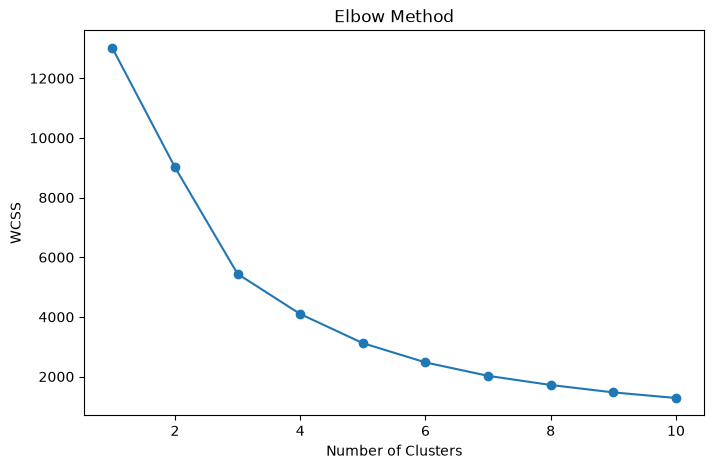

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [12]:
#training KMeans with the optimal number of clusters
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [13]:
rfm["Cluster"] = clusters

In [14]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,Cluster
0,326,1,77183.60,1,1,5,7,Potential,3
1,2,7,4310.00,5,5,5,15,Champion,0
2,75,4,1797.24,2,4,4,10,Loyal,0
3,19,1,1757.55,4,1,4,9,Potential,0
4,310,1,334.40,1,1,2,4,At Risk,1


In [15]:
#cluster counts
rfm["Cluster"].value_counts()

Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64

In [16]:
#cluster analysis
cluster_summary = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1353.625312
1,248.075914,1.552015,478.848773
2,7.384615,82.538462,127187.959231
3,15.500000,22.333333,12690.500392


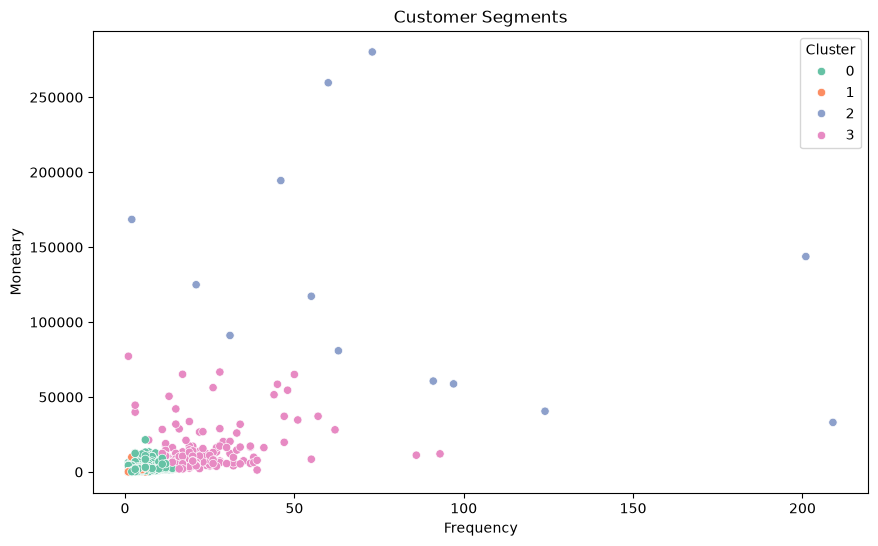

In [17]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segments")
plt.show()

In [18]:
#Silhouette Score
score = silhouette_score(X_scaled, rfm["Cluster"])

print("Silhouette Score:", score)

Silhouette Score: 0.6162275299061803


In [20]:
cluster_summary.reset_index()

,Cluster,Recency,Frequency,Monetary
0,0,43.702685,3.682711,1353.625312
1,1,248.075914,1.552015,478.848773
2,2,7.384615,82.538462,127187.959231
3,3,15.500000,22.333333,12690.500392


In [21]:
#Clusster Names
cluster_names = {
    0: "Regular Customers",
    1: "At Risk Customers",
    2: "VIP Customers",
    3: "Loyal Customers"
}

rfm["Customer_Segment"] = rfm["Cluster"].map(cluster_names)

In [22]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,Cluster,Customer_Segment
0,326,1,77183.60,1,1,5,7,Potential,3,Loyal Customers
1,2,7,4310.00,5,5,5,15,Champion,0,Regular Customers
2,75,4,1797.24,2,4,4,10,Loyal,0,Regular Customers
3,19,1,1757.55,4,1,4,9,Potential,0,Regular Customers
4,310,1,334.40,1,1,2,4,At Risk,1,At Risk Customers


In [23]:
#DBSCAN Clustering
from sklearn.cluster import DBSCAN

In [24]:
#Training DBSCAN
dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

db_clusters = dbscan.fit_predict(X_scaled)

In [25]:
rfm["DBSCAN_Cluster"] = db_clusters

In [26]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,Cluster,Customer_Segment,DBSCAN_Cluster
0,326,1,77183.60,1,1,5,7,Potential,3,Loyal Customers,-1
1,2,7,4310.00,5,5,5,15,Champion,0,Regular Customers,0
2,75,4,1797.24,2,4,4,10,Loyal,0,Regular Customers,0
3,19,1,1757.55,4,1,4,9,Potential,0,Regular Customers,0
4,310,1,334.40,1,1,2,4,At Risk,1,At Risk Customers,0


In [27]:
#counting the number of clusters 
rfm["DBSCAN_Cluster"].value_counts()

DBSCAN_Cluster
 0    4297
-1      41
Name: count, dtype: int64

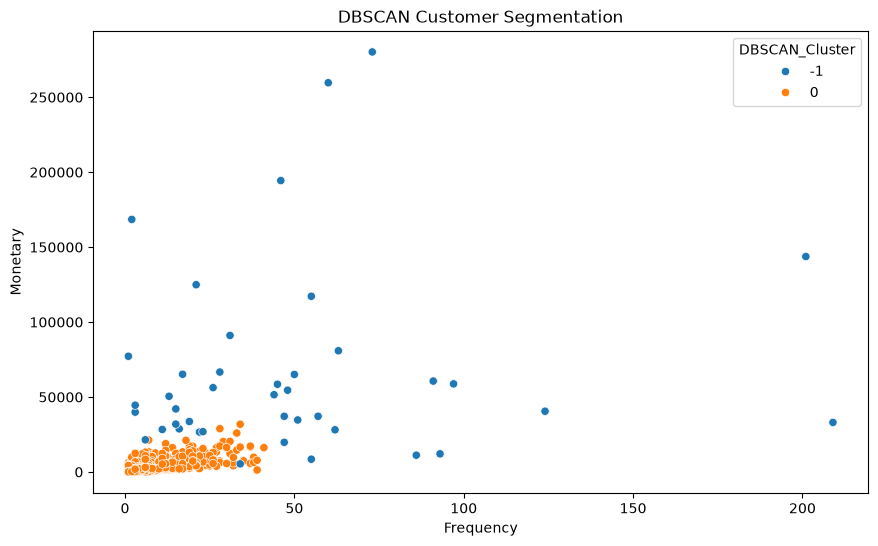

In [28]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="DBSCAN_Cluster",
    palette="tab10"
)

plt.title("DBSCAN Customer Segmentation")
plt.show()

In [29]:
#comparing KMeans and DBSCAN clustering results
print("K-Means Clusters")
print(rfm["Cluster"].value_counts())

print("\nDBSCAN Clusters")
print(rfm["DBSCAN_Cluster"].value_counts())

K-Means Clusters
Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64

DBSCAN Clusters
DBSCAN_Cluster
 0    4297
-1      41
Name: count, dtype: int64


In [30]:
rfm.to_csv(
    r"C:\Users\ASUS\OneDrive\Desktop\AI-Powered-Demand-Inventory-Intelligence\data\customer_segments.csv",
    index=False
)

print("customer_segments.csv saved successfully!")

customer_segments.csv saved successfully!
